In [1]:
import numpy as np
import jax
import jax.scipy as jsp
import jax.numpy as jnp
from jax import config
import jax_healpy as jhp
import matplotlib.pyplot as plt
import healpy as hp
import toml
config.update("jax_enable_x64", True)

import lineax as lx
import micmac 

## Parameters to create the *MICMAC* object

In [2]:
dictionary_params = {
    'general': {
        'disable_chex': False, # quick test parameters
        'classical_Gibbs': False, # to not sample for mixing matri alements, and have them fixed to their initial value 
        'bf_sampling': {
            'perturbation_eta_covariance': True,  # !! keep true to have optimized version for the Bf sampling -- needs step size Bf low enough
            'simultaneous_accept_rate': False,     # !! keep true to have optimized version for the Bf sampling with multipatch -- assumes noise to be uncorrelated between patches
            'use_alternative_Bf_sampling': False, # to use the alternative Bf sampling, which is more efficient for the sampling of Bf, to use - d^t N^{-1} B (B^t N^{-1} B)^{-1} B^t N^{-1} d + (s_c - s_c,ML)^t N_c^-1 (s_c - s_c,ML)
            # instead of - (d - B_c s_c)^t N^{-1} B 
        },
        'eta_sampling': {
            'biased_version': False, # to sample without the eta term in the Bf sampling 
            'suppress_low_modes': True, # to make eta band-limited 
            'use_mask_contribution_eta': True # to account for the mask in the computation of the noise contribution to the covariance of eta
        }
    },
    'scam': {
        'use_scam_step_size': True, # to use the step-size provided in the file, instead of the one provided in the toml file
        'burn_in_scam': 50, # Number of iterations for the burn-in before the adaptive step-size for the Metropolis-Hastings-within-Gibbs sampling of r and Bf
        'scam_iteration_updates': 40 # Number of iterations corresponding to the rate of update of the step-size for the Metropolis-Hastings-within-Gibbs sampling of r and Bf
    },
    'setup': {
        'nside': 128,
        'lmax': 256,
        'nstokes': 2,
        'lmin': 2,
        'n_iter': 3, # Number of iterations for Python estimation of alms
        'n_components': 3, # Number of components to sample, usually 3 (CMB + 2 foregrounds components)
        'pos_special_freqs': [0,-1], # position of the special frequencies in the frequency array, if not provided, the first and last frequencies will be considered as special frequencies
        'indexes_free_Bf': False, # Bf indexes that will be sampled
        'seed': 42 # seed for the begining of the chain
    },
    'cg_params': {
        'limit_iter_cg': 400, # Maximum number of iterations for the different CG 
        'limit_iter_cg_eta': 400, # Maximum number of iterations for the CG of eta
        'tolerance_CG': 1e-6, # Tolerance for the different CGs
        'atol_CG': 1e-6
    },
    'metropolis': {
        'step_size_Bf_1': 1e-4, # Provide step-size for the first column of Bf ; it can also be provided as a list 
        'step_size_Bf_2': 5e-5 # Provide step-size for the second column of Bf ; it can also be provided as a list 
    },
    'cmb_sampling': {
        'sample_r_Metropolis': True,
        'sample_C_inv_Wishart': False,
        'c_sampling': {
            'non_centered_moves': False,
            'use_binning': False, # WARNING: this option is not implemented yet, and will not work
            'save_intermediary_centered_moves': False,
            # 'binwidth': 1 # binwidth for power spectrum binning
        },
        'r_sampling': {
            'step_size_r': 5e-4, #1e-4 #5e-4 #1e-5 ???
            'limit_r_value': True,
            # 'min_r_value': 0, # default to None, only uncomment if you want to set a minimum value for r 
            'below_0_min_r_value': True, # to allow r to be below 0 while keeping C(r) positive definite
            'use_alm_sampling_r': False, # to sample r using the alms of the CMB map sampled
            'use_alm_sampling_r_wEE': False, # to sample r using the alms of the CMB map sampled
            # 'lmin_BB': 30 #TODO: to put to 30 with mask!!!
        }
    },
    'save_flags': {
        'save_CMB_chain_maps': False, # If true, all the sampled CMB maps which are marginalized over will be saved
        'save_eta_chain_maps': False, # If true, all the sampled eta maps which are marginalized over will be saved
        'save_s_c_spectra': False # If true, the s_c spectra will be saved
    },
    'instrument': {
        'instrument_name': 'SO_SAT' #example: 'LiteBIRD' or 'SO_SAT' # Either provide instrument name, then freq_inverse_noise and frequency_array will be taken from fgbuster,
        # or provide expcitely freq_inverse_noise and frequency_array with instrument_name="customized_instrument"
        # 'frequency_array': [90],
        # 'depth_p': [4]
    }, 
    'iterations': {
        'number_iterations_sampling': 5, #1000 #1500 #5000 #3000 #6000 # 1000 #2000 #5000 #1500 #2500 #300 #700 #1200 #125 #500 #1000 #2000 #400, # Maximum number of iterations for the sampling
        'number_iterations_done': 0, # Number of iterations already accomplished, in case the chain is resuming from a previous run 
    }
}


In [3]:
MICMAC_obj = micmac.create_MicmacSampler_from_dictionnary(dictionary_params, path_file_spv='', transform_to_root_dict=True)

Loading or creating the spv config from a yaml file
No spatial variability case

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f0
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
    f1
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None

>>> Tree of spv config after filling the missing values:
root
  nside_spv
    default: [0]
    f0
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
    f1
      default: [0]
      b0
        default: [0]
      b1
        default: [0]
      b2
        default: [0]
      b3
        default: [0]
Templates created [[[0 0 0 ... 0 0 0]
  [4 4 4 ... 4 4 4]]

 [[1 1 1 ... 1 1 1]
  [5 5 5 ... 5 5 5]]

 [[2 2 2 ... 2 2 2]
  [6 6 6 ... 6 6 6]]

 [[3 3 3 

## Retrieving the mask

0.10109456380208333

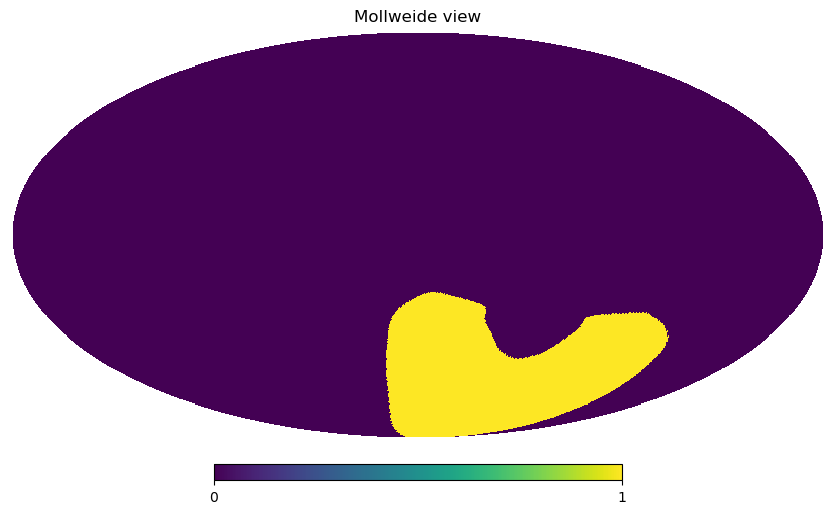

In [4]:
mask = np.ones(MICMAC_obj.n_pix, dtype=float)
mask = hp.ud_grade(hp.read_map('/Users/mag/Documents/Friendship/MICMAC_II/masks/mask_SO_SAT_apodized.fits', dtype=float), nside_out=MICMAC_obj.nside)
mask[mask > 0.3] = 1.0
mask[mask < 0.3] = 0

phi_ang, theta_ang = hp.pix2ang(MICMAC_obj.nside, np.arange(mask.size), lonlat=True)
mask[theta_ang>0] = 0

mask_indices = np.where(mask > 0)[0]
npix_mask = int(mask.sum())

hp.mollview(mask)

f_sky = mask.sum() / mask.size
f_sky 

In [5]:
ell_range = jnp.arange(MICMAC_obj.lmin, MICMAC_obj.lmax + 1)

## Preparing input maps

In [6]:
r_true = 1e-2

In [7]:
seed = 42 

In [8]:
np.random.seed(seed)
freq_maps_foregrounds = micmac.get_observation('SO_SAT', 'd0s0', nside=MICMAC_obj.nside, noise=False)[
    :, 1:, :
]  # keep only Q and U

['d0', 's0']


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [9]:
np.random.seed(seed+1)
(
    freq_maps,
    input_cmb_maps,
    theoretical_red_cov_r0_total,
    theoretical_red_cov_r1_tensor,
) = MICMAC_obj.generate_input_freq_maps_from_fgs(
    freq_maps_foregrounds, 
    r_true=r_true, 
    lmin_input=MICMAC_obj.lmin,
    return_only_freq_maps=False)

freq_maps = freq_maps * mask

Setting lmin to  2
Calculating spectra from CAMB !
Calculating spectra from CAMB !


In [10]:
init_mixing_matrix_obj = micmac.InitMixingMatrix(
    freqs=MICMAC_obj.frequency_array,
    ncomp=MICMAC_obj.n_components,
    pos_special_freqs=MICMAC_obj.pos_special_freqs,
    templates=MICMAC_obj.templates,
)
exact_params_mixing_matrix = init_mixing_matrix_obj.init_params()
exact_params_mixing_matrix

>>> init params built with spectral params: 1.54 20.0 -3.0


array([0.33858815, 0.02963068, 0.00998213, 0.00328725, 0.00979233,
       0.05147511, 0.12913911, 0.44076761])

## Preparing intermediaries (mixing matrix to use, noise covariance, ...)

In [11]:
params_mixing_matrix_sample = jnp.copy(exact_params_mixing_matrix)

mixing_matrix_sampled = MICMAC_obj.get_B_from_params(params_mixing_matrix_sample, jax_use=True) * mask

red_cov_matrix_sqrt = micmac.get_sqrt_reduced_matrix_from_matrix_jax(
    theoretical_red_cov_r0_total + r_true * theoretical_red_cov_r1_tensor
)

In [12]:
instrument = micmac.get_instrument(MICMAC_obj.instrument_name)

freq_inverse_noise = micmac.get_noise_covar_extended(
    instrument['depth_p'], MICMAC_obj.nside
)  # MICMAC_obj.freq_inverse_noise

MICMAC_obj.freq_inverse_noise = freq_inverse_noise * mask

N_c = micmac.get_inv_BtinvNB(MICMAC_obj.freq_inverse_noise, mixing_matrix_sampled, jax_use=True)[0,0,:] * hp.nside2resol(MICMAC_obj.nside) ** 2

invBtinvNB = micmac.get_inv_BtinvNB(MICMAC_obj.freq_inverse_noise, mixing_matrix_sampled, jax_use=True) * hp.nside2resol(MICMAC_obj.nside) ** 2

BtinvN_sqrt = micmac.get_BtinvN(jnp.sqrt(MICMAC_obj.freq_inverse_noise), mixing_matrix_sampled, jax_use=True)

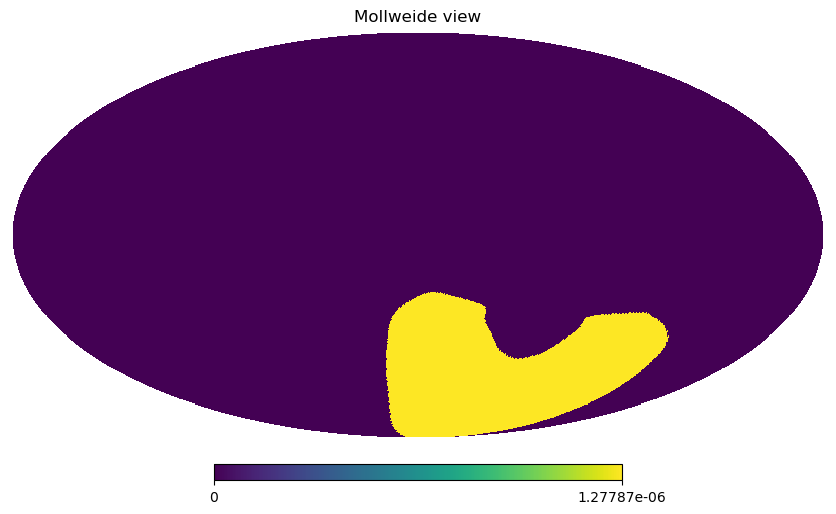

In [13]:
hp.mollview(N_c)

## Preparing right hand side terms

### Fluctuation right hand side 

In [14]:
jax_key_PNRG = jax.random.PRNGKey(seed+2)

jax_key_PNRG, jax_key_PNRG_xi = jax.random.split(jax_key_PNRG)  # Splitting of the random key to generate a new one

print('Recalculating xi !')
map_random_realization_xi = jax.random.normal(
    jax_key_PNRG_xi, shape=(MICMAC_obj.nstokes, MICMAC_obj.n_pix)
) / jhp.nside2resol(MICMAC_obj.nside)

jax_key_PNRG, *jax_key_PNRG_chi = jax.random.split(
    jax_key_PNRG, MICMAC_obj.n_frequencies + 1
)  # Splitting of the random key to generate a new one
# If no random maps are provided, then it is computed within the routine
print('Recalculating chi !')

def fmap(random_key):
    random_map = jax.random.normal(random_key, shape=(MICMAC_obj.nstokes, MICMAC_obj.n_pix))
    # return MICMAC_obj.get_band_limited_maps(random_map)
    return random_map

map_random_realization_chi = jax.vmap(fmap)(
    jnp.array(jax_key_PNRG_chi)
)  # Generating a different random Gaussian map for each frequency


# Computation of the right side member of the CG

# First right member: xi
right_member_1 = map_random_realization_xi

# Second right member:
## Computation of C^{1/2} N_c^{-1/2} \chi
N_c_inv = jnp.copy(N_c)
N_c_inv = N_c_inv.at[..., mask != 0].set(
    1 / N_c[mask != 0] / jhp.nside2resol(MICMAC_obj.nside) ** 2
)
N_c_inv_repeat = jnp.broadcast_to(N_c_inv, (MICMAC_obj.nstokes, MICMAC_obj.n_pix)).ravel()
# Repeat N_c_inv for each Stokes parameter, for speed-up afterwards

## Computation of N_c^{-1/2} \chi = (E^t (B^t N^{-1} B)^{-1} E) E^t (B^t N^{-1} B)^{-1} B^t N^{-1/2} \chi
right_member_2_part = (
    jnp.einsum('kcp,cfp,fsp->ksp', invBtinvNB, BtinvN_sqrt, map_random_realization_chi)[0] * N_c_inv
)  # [0] for selecting CMB component of the random variable
# First compute N_c^{-1/2} \chi
right_member_2 = micmac.maps_x_red_covariance_cell_JAX(
    right_member_2_part, red_cov_matrix_sqrt, nside=MICMAC_obj.nside, lmin=MICMAC_obj.lmin, n_iter=MICMAC_obj.n_iter
)
# Then apply C^{1/2} to N_c^{-1/2} \chi

# right_member = (right_member_1 + right_member_2).ravel()
# right_member_fluctuation = (MICMAC_obj.get_band_limited_maps(right_member_1).ravel() + right_member_2.ravel()).reshape(-1, MICMAC_obj.n_pix)

right_member_fluctuation = MICMAC_obj.get_band_limited_maps(right_member_1) + right_member_2


Recalculating xi !
Recalculating chi !


### WF right hand side 

In [15]:
## Preparation of the right member of the CG
s_cML = micmac.get_Wd(freq_inverse_noise, mixing_matrix_sampled, freq_maps, jax_use=True)[0]

right_member_WF = s_cML


### Total right hand side term

In [16]:
right_member = right_member_fluctuation + right_member_WF
right_member.shape

(2, 196608)

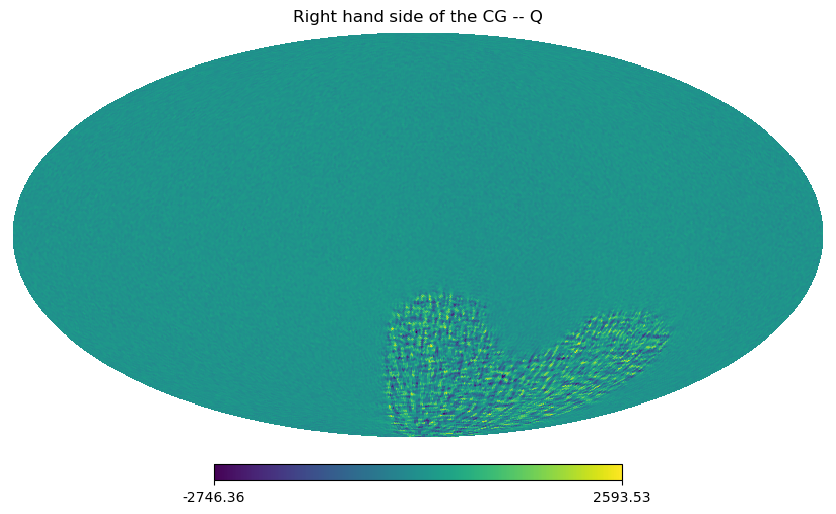

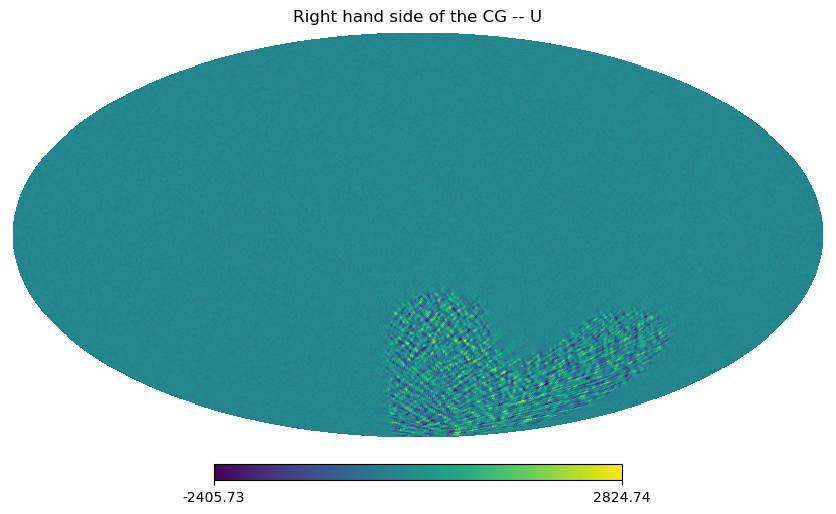

In [17]:
hp.mollview(right_member[0], title='Right hand side of the CG -- Q')
hp.mollview(right_member[1], title='Right hand side of the CG -- U')

## Prepare the system matrix $(1 + C^{1/2} N^{-1} C^{1/2})$

In [18]:
# Building N_c^{-1} and padding 0 outside the obserevd area
N_c_inv = jnp.zeros_like(N_c)
N_c_inv = N_c_inv.at[..., mask != 0].set(1 / N_c[mask != 0])
N_c_inv_repeat = jnp.broadcast_to(
    N_c_inv, (MICMAC_obj.nstokes, MICMAC_obj.n_pix)
).ravel()  ## Repeat N_c_inv for each Stokes parameter, for speed-up afterwards


# N_c_inv_mask_indices = jnp.zeros(mask_indices, dtype=float)
N_c_inv_mask_indices = 1. / N_c[mask != 0]
N_c_inv_mask_indices_repeat = jnp.broadcast_to(
    N_c_inv_mask_indices, (MICMAC_obj.nstokes, npix_mask)
).ravel()  ## Repeat N_c_inv for each Stokes parameter, for speed-up afterwards


## Preparing the operator C_approx^{1/2}
first_part_left = lambda x: micmac.maps_x_red_covariance_cell_JAX(
    x.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix)),
    red_cov_matrix_sqrt,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
).ravel()

## Preparing the operator N_c^{-1}
def second_part_left(x):
    return x * N_c_inv_repeat


In [19]:

func_left_term = lambda x: x.ravel() + first_part_left(second_part_left(first_part_left(x))).ravel()

func_lineax = lx.FunctionLinearOperator(
    func_left_term, 
    input_structure=jax.ShapeDtypeStruct((MICMAC_obj.nstokes*MICMAC_obj.n_pix,),jnp.float64), 
    tags=(lx.positive_semidefinite_tag, lx.symmetric_tag)
)


### Preparing a preconditioner corresponding to simply an inverse of the equivalent system matrix in harmonic domain

In [20]:
 ## Assuming a harmonic noise with the pixel average of the mixing matrix

freq_noise_c_ell = micmac.get_true_Cl_noise(np.array(instrument['depth_p']), MICMAC_obj.lmax) 

noise_c_ell = micmac.get_inv_BtinvNB_c_ell(freq_noise_c_ell, mixing_matrix_sampled.mean(axis=2))[0, 0, MICMAC_obj.lmin:]
## Getting N_c^{-1} for the harmonic noise covariance
red_inv_noise_c_ell = jnp.linalg.pinv(
    micmac.get_reduced_matrix_from_c_ell_jax(
        jnp.stack([noise_c_ell, noise_c_ell, jnp.zeros_like(noise_c_ell)])
    )
) 

red_preconditioner_s_c = jnp.linalg.pinv(
    jnp.eye(MICMAC_obj.nstokes)
    + jnp.einsum('lij,ljk,lkm->lim', red_cov_matrix_sqrt, red_inv_noise_c_ell, red_cov_matrix_sqrt) 
) 

precond_func = lambda x: micmac.maps_x_red_covariance_cell_JAX(
    x.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix)),
    red_preconditioner_s_c,
    nside=MICMAC_obj.nside,
    lmin=MICMAC_obj.lmin,
    n_iter=MICMAC_obj.n_iter,
).ravel()

In [21]:
max_iter_CG = 700 #200 #400

tolerance_CG = 1e-5

In [22]:
## Preparation of the initial guess
initial_guess = jnp.copy(right_member)

In [23]:
solver = lx.CG(rtol=tolerance_CG, atol=tolerance_CG, max_steps=max_iter_CG, norm=lx._norm.rms_norm,)
throw = False


options = dict()
options['y0'] = jnp.zeros_like(initial_guess.ravel())


options_w_precond = dict()

options_w_precond['y0'] = jnp.zeros_like(initial_guess.ravel())
options_w_precond['preconditioner'] = lx.FunctionLinearOperator(
    precond_func, 
    input_structure=jax.ShapeDtypeStruct((MICMAC_obj.nstokes*MICMAC_obj.n_pix,),jnp.float64), 
    tags=(lx.positive_semidefinite_tag, lx.symmetric_tag)
)


In [24]:
%%time
result_sp, iterations = jsp.sparse.linalg.cg(
    func_left_term,
    right_member.ravel(),
    x0=jnp.zeros_like(initial_guess.ravel()),
    tol=tolerance_CG,
    maxiter=max_iter_CG,
)

result_sp = result_sp.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))


CPU times: user 2min 48s, sys: 20.4 s, total: 3min 8s
Wall time: 27.5 s


In [25]:
%%time

solution = lx.linear_solve(func_lineax, right_member.ravel(), solver=solver, throw=throw, options=options)
print("solved in", solution.stats['num_steps'], "steps")
result_lineax = solution.value.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))

solved in 414 steps
CPU times: user 4min 4s, sys: 29.7 s, total: 4min 34s
Wall time: 44.2 s


In [26]:
%%time
result_sp_w_precond, iterations_w_precond = jsp.sparse.linalg.cg(
    func_left_term,
    right_member.ravel(),
    x0=initial_guess.ravel(),
    tol=tolerance_CG,
    maxiter=max_iter_CG,
    M=precond_func,
)

result_sp_w_precond = result_sp_w_precond.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))


CPU times: user 8min 28s, sys: 1min, total: 9min 29s
Wall time: 1min 28s


In [27]:
%%time

solution_w_precond = lx.linear_solve(func_lineax, right_member.ravel(), solver=solver, throw=throw, options=options_w_precond)
print("solved in", solution_w_precond.stats['num_steps'], "steps")
result_lineax_w_precond = solution_w_precond.value.reshape((MICMAC_obj.nstokes, MICMAC_obj.n_pix))

solved in 700 steps
CPU times: user 9min 54s, sys: 1min 7s, total: 11min 2s
Wall time: 1min 33s


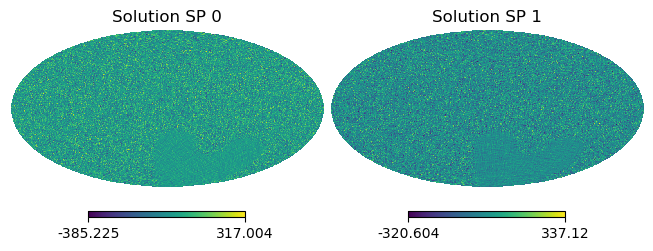

In [28]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_sp[i],
        title=f'Solution SP {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

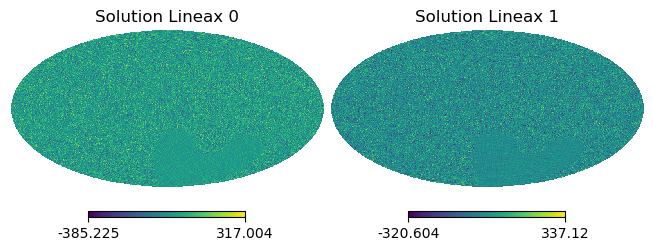

In [29]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_lineax[i],
        title=f'Solution Lineax {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

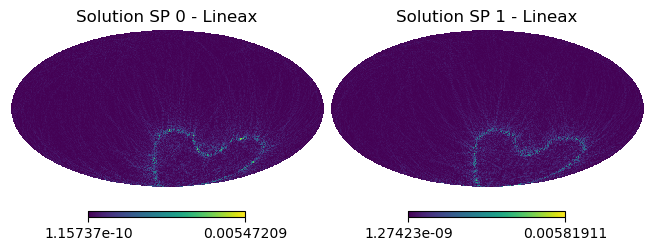

In [30]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        np.abs(result_sp[i]-result_lineax[i]),
        title=f'Solution SP {i} - Lineax',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

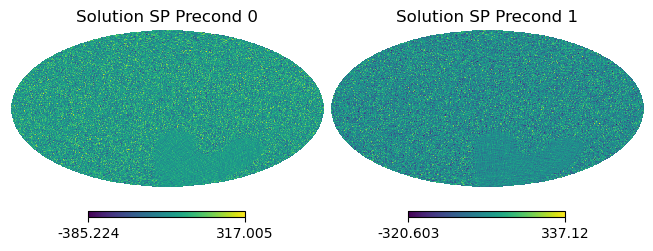

In [31]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_sp_w_precond[i],
        title=f'Solution SP Precond {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

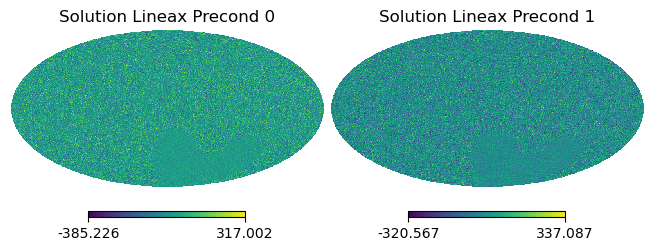

In [32]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        result_lineax_w_precond[i],
        title=f'Solution Lineax Precond {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )

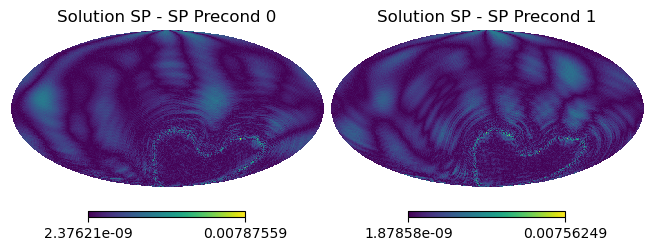

In [33]:
for i in range(MICMAC_obj.nstokes):
    hp.mollview(
        np.abs(result_sp[i] - result_sp_w_precond[i]),
        title=f'Solution SP - SP Precond {i}',
        sub=(1, MICMAC_obj.nstokes, i + 1),
        )